In [74]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [75]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'} 


In [76]:
webpage = requests.get('https://www.ambitionbox.com/list-of-companies?page=1',headers = headers).text

In [5]:
soup=BeautifulSoup(webpage,'lxml')

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
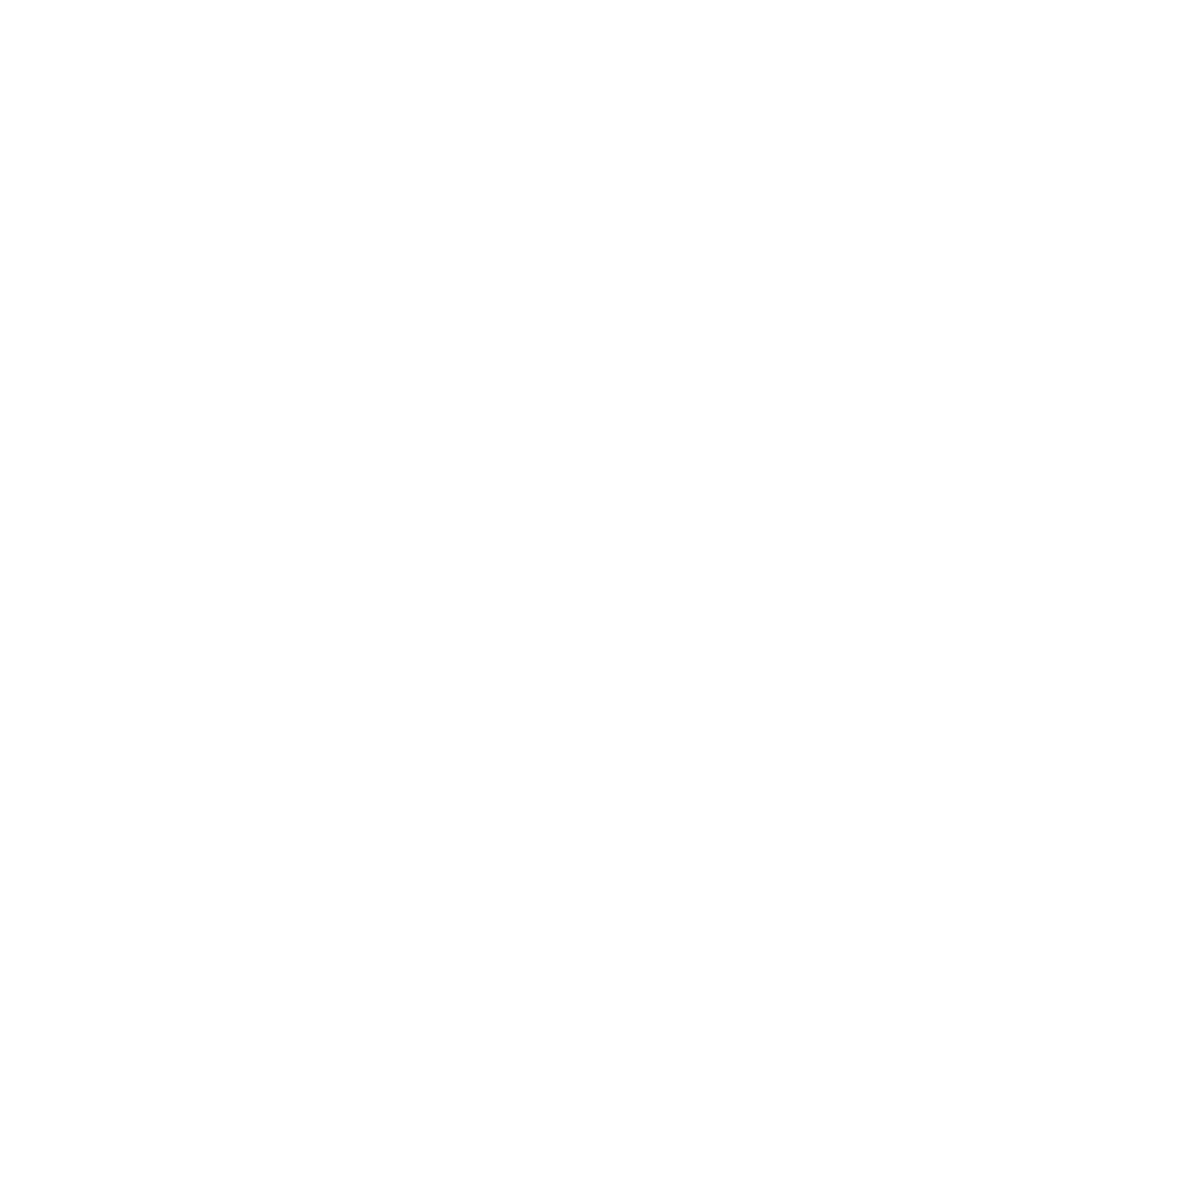

In [6]:
print(soup.prettify())

In [7]:
companies = soup.find_all('h2', class_='companyCardWrapper__companyName')

for company in companies:
    print(company.text.strip())

TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
IBM


In [8]:
ratings = soup.find_all(class_="rating_text rating_text--md")

for rating in ratings :
    print(rating.text.strip())

3.3
3.7
3.6
3.7
3.6
3.8
3.5
3.4
3.9
3.3
3.6
3.9
4.4
3.6
3.6
3.9
3.9
4.6
3.6
3.9


In [51]:
rating_counts = soup.find_all('span',class_="companyCardWrapper__companyRatingCount")

for rating in rating_counts:
    print(rating.text.strip())

(1.2L)
(74.8k)
(66.1k)
(62.4k)
(54.5k)
(53.5k)
(49.7k)
(46.8k)
(46.6k)
(44k)
(43.2k)
(39.4k)
(33.9k)
(33.9k)
(32.8k)
(32.2k)
(27.7k)
(27.4k)
(26.9k)
(26.1k)


In [52]:
#Actual Working

In [9]:
companies = soup.find_all(class_='companyCardWrapper__primaryInformation')    

In [65]:
mnc = []
rating=[]
review_count = []


for i in companies:
    mnc.append(i.find(class_='companyCardWrapper__companyName').text.strip())
    rating.append(i.find(class_='rating_text rating_text--md').text.strip())
    review_count.append(i.find('span',class_="companyCardWrapper__companyRatingCount").text.strip())


In [66]:
mnc
rating
review_count

['(1.2L)',
 '(74.8k)',
 '(66.1k)',
 '(62.4k)',
 '(54.5k)',
 '(53.5k)',
 '(49.7k)',
 '(46.8k)',
 '(46.6k)',
 '(44k)',
 '(43.2k)',
 '(39.4k)',
 '(33.9k)',
 '(33.9k)',
 '(32.8k)',
 '(32.2k)',
 '(27.7k)',
 '(27.4k)',
 '(26.9k)',
 '(26.1k)']

In [69]:
df=pd.DataFrame({'mnc':mnc,
   'rating':rating,
   'reviews':review_count})

In [71]:
df

,mnc,rating,reviews
0,TCS,3.3,(1.2L)
1,Accenture,3.7,(74.8k)
2,Wipro,3.6,(66.1k)
3,Cognizant,3.7,(62.4k)
4,Capgemini,3.6,(54.5k)
5,HDFC Bank,3.8,(53.5k)
6,Infosys,3.5,(49.7k)
7,HCLTech,3.4,(46.8k)
8,ICICI Bank,3.9,(46.6k)
9,Tech Mahindra,3.3,(44k)


In [113]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time 
mnc = []
rating=[]
review_count = []


for i in range(1,500):
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}    
    webpage = requests.get(f"https://www.ambitionbox.com/list-of-companies?page={i}",headers = headers).text
    soup=BeautifulSoup(webpage,'lxml')    
    companies = soup.find_all(class_="companyCardWrapper")
    for j in companies:
        try :
            mnc.append(j.find(class_='companyCardWrapper__companyName').text.strip())
        except:
            mnc.append(np.nan)
        try :
            rating.append(j.find(class_='rating_text rating_text--md').text.strip())
        except:
            rating.append(np.nan)
        try :
            review_count.append(j.find('span',class_="companyCardWrapper__companyRatingCount").text.strip())        
        except:
            review_count.append(np.nan)
    time.sleep(1) 
        
df=pd.DataFrame({'mnc':mnc,
   'rating':rating,
   'reviews':review_count})

In [116]:
df.index = np.arange(1, len(df) + 1)

In [118]:
df

,mnc,rating,reviews
1,TCS,3.3,(1.2L)
2,Accenture,3.7,(74.8k)
3,Wipro,3.6,(66.1k)
4,Cognizant,3.7,(62.4k)
5,Capgemini,3.6,(54.5k)
...,...,...,...
9976,FitterFly,3.4,(113)
9977,Avant Garde Industries,4.7,(113)
9978,U&D Square Solutions,3.7,(113)
9979,Pigeon India,4.0,(113)


In [121]:
df.to_csv('company-review')